In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/quora-question-pairs/train.csv.zip
/kaggle/input/competitions/quora-question-pairs/sample_submission.csv.zip
/kaggle/input/competitions/quora-question-pairs/test.csv
/kaggle/input/competitions/quora-question-pairs/test.csv.zip


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [3]:
df=pd.read_csv("/kaggle/input/competitions/quora-question-pairs/train.csv.zip")

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.shape

(404290, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [7]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
8351,8351,16285,16286,Why weren't soldiers of Subhash Chandra Bose's...,Why didn't the INA get integrated in the India...,1
87890,87890,147940,147941,To what degree do authors censor their final m...,"How often, or what's the rule used for 9gag or...",0
336285,336285,463622,107788,How do I deal with a heartbreak of someone you...,What's the best way to deal with heartbreak?,0
30805,30805,56845,56846,What are the pros and cons of working in the r...,What are some of the best jokes to start a con...,0
354579,354579,185179,310780,What will happen if sun dies?,What happens to a planetary system when its su...,1


In [8]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [11]:
(df['is_duplicate'].value_counts())/(df['is_duplicate'].count()) *100

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64

<Axes: xlabel='is_duplicate'>

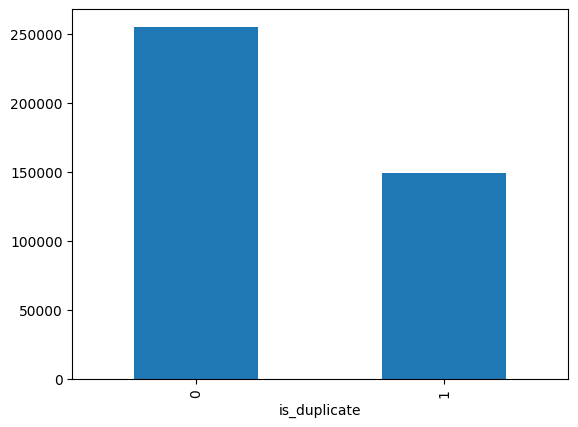

In [12]:
df['is_duplicate'].value_counts().plot(kind="bar")

In [13]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print("Number of unique questions:",np.unique(qid).shape[0])
x=qid.value_counts()>1
print("number of duplicated questions",x[x].shape[0])

Number of unique questions: 537933
number of duplicated questions 111780


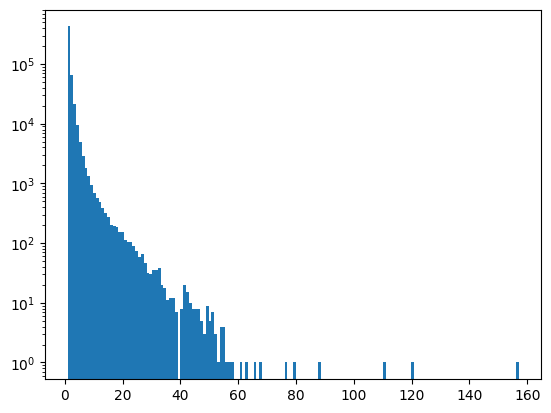

In [14]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')

# Simplest Approach

In [15]:
new_df=df.sample(30000)

In [16]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [17]:
new_df.duplicated().sum()

np.int64(0)

In [18]:
ques_df=new_df[['question1','question2']]

In [19]:
ques_df.head()

,question1,question2
402438,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh..."
15677,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?
326873,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...
353612,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?
254537,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?


In [20]:
from sklearn.feature_extraction.text import CountVectorizer

questions=(ques_df['question1']).tolist()+(ques_df['question2']).tolist()
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [21]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [22]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
402438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
326873,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
353612,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
254537,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [23]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [24]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
402438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
326873,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
353612,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
254537,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [26]:
X_train.shape,X_test.shape

((24000, 6000), (6000, 6000))

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7433333333333333

In [28]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.728

# Feature extraction

In [29]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()

In [30]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
402438,402438,535918,535919,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh...",0,88,117
15677,15677,29933,29934,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?,0,66,43
326873,326873,42549,28647,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...,1,40,76
353612,353612,482697,482698,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?,0,40,44
254537,254537,5123,30048,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?,1,44,44


In [31]:
new_df['q1_num_wwords']=new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_wwords']=new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords
402438,402438,535918,535919,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh...",0,88,117,16,23
15677,15677,29933,29934,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?,0,66,43,13,9
326873,326873,42549,28647,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...,1,40,76,8,15
353612,353612,482697,482698,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?,0,40,44,9,9
254537,254537,5123,30048,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?,1,44,44,8,8


In [32]:
def common_words(row):
    w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [33]:
new_df['word_common']=new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common
402438,402438,535918,535919,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh...",0,88,117,16,23,4
15677,15677,29933,29934,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?,0,66,43,13,9,3
326873,326873,42549,28647,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...,1,40,76,8,15,5
353612,353612,482697,482698,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?,0,40,44,9,9,5
254537,254537,5123,30048,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?,1,44,44,8,8,4


In [34]:
def total_words(row):
    w1=set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [35]:
new_df['total_words']=new_df.apply(total_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words
402438,402438,535918,535919,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh...",0,88,117,16,23,4,37
15677,15677,29933,29934,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?,0,66,43,13,9,3,21
326873,326873,42549,28647,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...,1,40,76,8,15,5,20
353612,353612,482697,482698,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?,0,40,44,9,9,5,18
254537,254537,5123,30048,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?,1,44,44,8,8,4,16


In [36]:
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
402438,402438,535918,535919,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh...",0,88,117,16,23,4,37,0.11
15677,15677,29933,29934,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?,0,66,43,13,9,3,21,0.14
326873,326873,42549,28647,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...,1,40,76,8,15,5,20,0.25
353612,353612,482697,482698,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?,0,40,44,9,9,5,18,0.28
254537,254537,5123,30048,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?,1,44,44,8,8,4,16,0.25


# Analysis in new features

minimum characters: 1
maximum characters: 298
Average no of  characters: 59


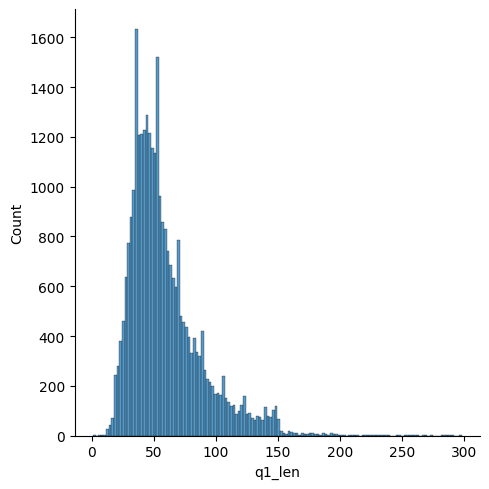

In [37]:
sns.displot(new_df['q1_len'])
print("minimum characters:",new_df['q1_len'].min())
print("maximum characters:",new_df['q1_len'].max())
print("Average no of  characters:",int(new_df['q1_len'].mean()))

minimum characters: 3
maximum characters: 1151
Average no of  characters: 60


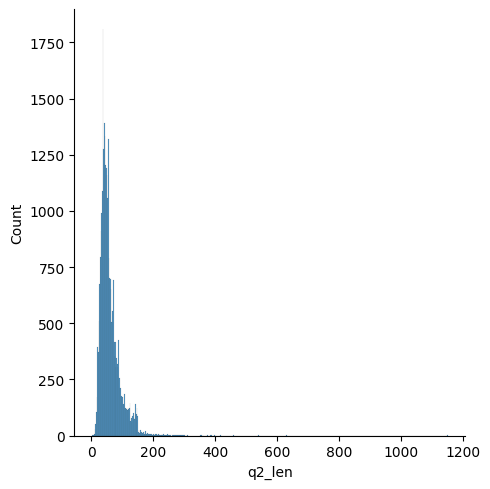

In [38]:
sns.displot(new_df['q2_len'])
print("minimum characters:",new_df['q2_len'].min())
print("maximum characters:",new_df['q2_len'].max())
print("Average no of  characters:",int(new_df['q2_len'].mean()))

minimum characters: 1
maximum characters: 64
Average no of  characters: 10


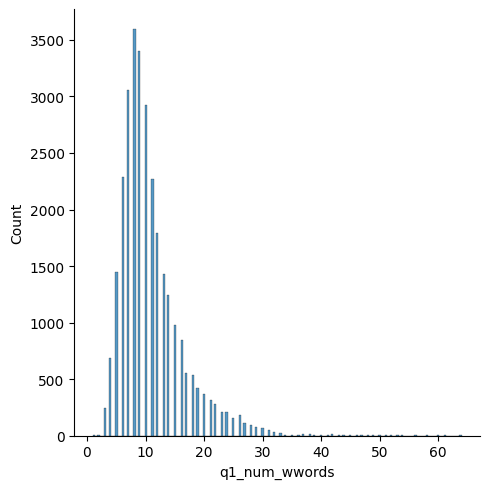

In [39]:
sns.displot(new_df['q1_num_wwords'])
print("minimum characters:",new_df['q1_num_wwords'].min())
print("maximum characters:",new_df['q1_num_wwords'].max())
print("Average no of  characters:",int(new_df['q1_num_wwords'].mean()))

minimum characters: 1
maximum characters: 237
Average no of  characters: 11


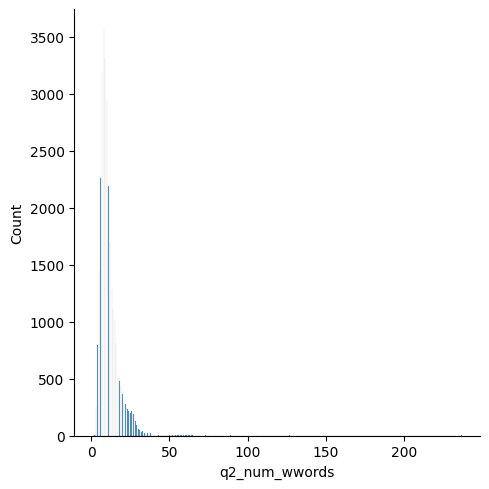

In [40]:
sns.displot(new_df['q2_num_wwords'])
print("minimum characters:",new_df['q2_num_wwords'].min())
print("maximum characters:",new_df['q2_num_wwords'].max())
print("Average no of  characters:",int(new_df['q2_num_wwords'].mean()))

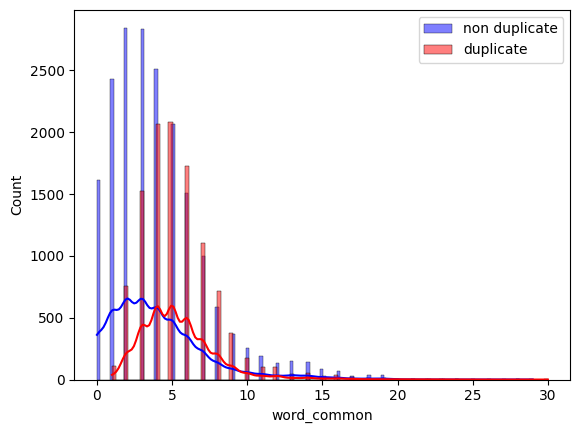

In [41]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['word_common'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['word_common'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

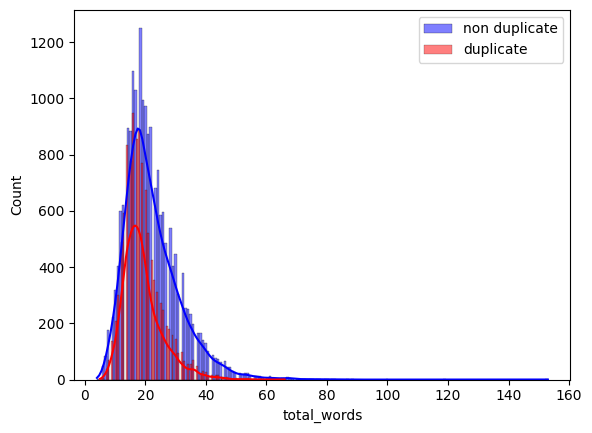

In [42]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['total_words'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['total_words'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

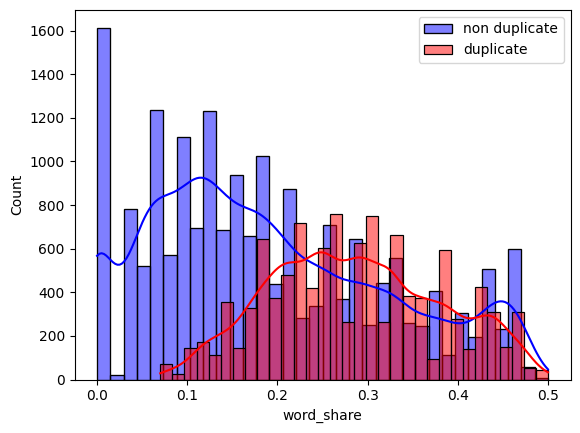

In [43]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['word_share'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['word_share'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

# Making New Data

In [44]:
final_df=new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
402438,0,88,117,16,23,4,37,0.11
15677,0,66,43,13,9,3,21,0.14
326873,1,40,76,8,15,5,20,0.25
353612,0,40,44,9,9,5,18,0.28
254537,1,44,44,8,8,4,16,0.25


In [45]:
temp_df=temp_df.drop(columns=['is_duplicate'])

In [46]:
final_df=pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
402438,0,88,117,16,23,4,37,0.11,0,0,...,0,0,0,0,0,0,0,0,0,0
15677,0,66,43,13,9,3,21,0.14,0,0,...,0,0,0,0,0,0,0,0,0,0
326873,1,40,76,8,15,5,20,0.25,0,0,...,0,0,0,0,0,0,0,0,0,0
353612,0,40,44,9,9,5,18,0.28,0,0,...,0,0,0,0,0,0,0,0,0,0
254537,1,44,44,8,8,4,16,0.25,0,0,...,0,0,0,0,1,0,0,0,0,0


In [47]:
X=final_df.iloc[:,1:].values
X

array([[ 88., 117.,  16., ...,   0.,   0.,   0.],
       [ 66.,  43.,  13., ...,   0.,   0.,   0.],
       [ 40.,  76.,   8., ...,   0.,   0.,   0.],
       ...,
       [118.,  59.,  22., ...,   0.,   0.,   0.],
       [ 53.,  72.,  10., ...,   0.,   0.,   0.],
       [ 39.,  34.,   8., ...,   0.,   0.,   0.]])

In [48]:
y=final_df.iloc[:,0].values
y

array([0, 0, 1, ..., 0, 0, 1])

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

# training new data

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7658333333333334

In [51]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.771

# Text preprocessing in new data

In [52]:
ques_df=new_df[['question1','question2']]

In [53]:
ques_df.head()

,question1,question2
402438,I had my wisdom teeth pulled years ago and dev...,"I have fat only in my torso, neck and face. Wh..."
15677,"I am skinny, is it still unhealthy to consume ...",Should I consume more sugar if I do sports?
326873,What could be the basic purpose of life?,Wanna ask someone please. What is life? And wh...
353612,What is it like to ride a Greyhound bus?,What's it like to be a Greyhound bus driver?
254537,What are some new year resolutions for 2017?,What is your New Year's resolution for 2017?


## Remove Puntcuation

In [54]:
import string
exclude=string.punctuation
def remove_punc(text):
  return text.translate(str.maketrans('','',exclude))

## remove stopwords

In [55]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [56]:
from nltk.corpus import stopwords
def remove_stopwords(text):
  new_text=[]
  for word in text.split():
    if word in stopwords.words('english'):
      new_text.append('')
    else:
      new_text.append(word)
  return " ".join(new_text)

## Stemming

In [57]:
from nltk.stem.porter import PorterStemmer

In [58]:
ps=PorterStemmer()
def stem_words(text):
  return " ".join([ps.stem(word) for word in text.split()])

## all preproceesing functions

In [59]:
def preprocess_text(text):
    text=text.lower()
    text = remove_punc(text)
    text = remove_stopwords(text)
    text = stem_words(text)
    return text

In [60]:
ques_df[['question1', 'question2']]=ques_df[['question1', 'question2']].map(preprocess_text)
ques_df.head()

/tmp/ipykernel_16/2585961696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ques_df[['question1', 'question2']]=ques_df[['question1', 'question2']].map(preprocess_text)


,question1,question2
402438,wisdom teeth pull year ago develop concuss sym...,fat torso neck face kind exercis perform lose ...
15677,skinni still unhealthi consum lot sugar daili,consum sugar sport
326873,could basic purpos life,wanna ask someon pleas life purpos life
353612,like ride greyhound bu,what like greyhound bu driver
254537,new year resolut 2017,new year resolut 2017


# Applying tfidf vectorizer

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [62]:
tfidf=TfidfVectorizer()
questions=(ques_df['question1']).tolist()+(ques_df['question2']).tolist()
tfidf=TfidfVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(tfidf.fit_transform(questions).toarray(),2)

In [63]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [64]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
402438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
326873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
353612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
254537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
final_df_preprocess=new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df_preprocess.shape)
final_df_preprocess.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
402438,0,88,117,16,23,4,37,0.11
15677,0,66,43,13,9,3,21,0.14
326873,1,40,76,8,15,5,20,0.25
353612,0,40,44,9,9,5,18,0.28
254537,1,44,44,8,8,4,16,0.25


In [66]:
final_df_preprocess=pd.concat([final_df_preprocess,temp_df],axis=1)
print(final_df_preprocess.shape)
final_df_preprocess.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
402438,0,88,117,16,23,4,37,0.11,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15677,0,66,43,13,9,3,21,0.14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
326873,1,40,76,8,15,5,20,0.25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
353612,0,40,44,9,9,5,18,0.28,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
254537,1,44,44,8,8,4,16,0.25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
X_P=final_df.iloc[:,1:].values
X_P

array([[ 88., 117.,  16., ...,   0.,   0.,   0.],
       [ 66.,  43.,  13., ...,   0.,   0.,   0.],
       [ 40.,  76.,   8., ...,   0.,   0.,   0.],
       ...,
       [118.,  59.,  22., ...,   0.,   0.,   0.],
       [ 53.,  72.,  10., ...,   0.,   0.,   0.],
       [ 39.,  34.,   8., ...,   0.,   0.,   0.]])

In [68]:
y_p=final_df.iloc[:,0].values
y_p

array([0, 0, 1, ..., 0, 0, 1])

In [69]:
X_train,X_test,y_train,y_test=train_test_split(X_P,y_p,test_size=0.2,random_state=1)

## Model training with tfidf

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.772